# 환경설정

In [1]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib').setLevel(logging.ERROR)
# ── 한국어 폰트 설정 ──────────────────────────────────────────
import matplotlib.font_manager as fm
font_dirs = ['/usr/share/fonts/truetype/nanum']
font_files = fm.findSystemFonts(fontpaths=font_dirs)
for ff in font_files:
    fm.fontManager.addfont(ff)

# ── 스타일 설정 ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'NanumBarunGothic',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.unicode_minus': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 110,
})

# 경사하강법

## 1. 도함수의 정의와 계산 (기울기 도출)

- **강의 4, 7페이지:** 특정 점에서의 순간적인 변화율을 구하는 미분의 정의 극한값 $\lim_{h\to 0}\frac{f(x+h)-f(x)}{h} = f'(x)$ 이 등장합니다. 또한 복잡한 함수는 연쇄법칙(Chain rule) 등을 통해 계산할 수 있습니다.


- **코드 적용:** 손실함수 $L(w)$를 미분 공식을 통해 직접 계산하여 `dL(w)` 함수를 정의합니다. 이는 현재 가중치($w$) 지점에서 함수가 어느 방향으로 얼마나 기울어져 있는지(접선의 기울기)를 산출하는 과정입니다.

## 2. 테일러 급수와 접선의 방정식 (1차 근사)

- **강의 13, 15페이지:** 함수를 무한한 다항식의 합으로 표현하는 테일러 급수 $f(x) = f(x^*) + f'(x^*)(x-x^*) + \frac{f''(x^*)}{2!}(x-x^*)^2 + \cdots$ 이론이 설명되어 있습니다.

- **코드 적용:** 코드에서 접선을 그리는 수식은 위 테일러 급수에서 2차 이상의 항을 생략한 **1차 테일러 근사** 식인 $f(x) \approx f(x^*) + f'(x^*)(x-x^*)$ 와 완벽히 동일합니다.

## 3. 경사하강법의 이동 규칙 (오차 감소 원리)

- **강의 15페이지 (응용):** 테일러 전개식의 원리에 따라, 1차 근사식에 이동 거리 $x - x^* = -\eta f'(x^*)$ 를 대입하면 $f(x) \approx f(x^*) - \eta f'(x^*)^2$ 가 됩니다.

- **코드 적용:** 도함수의 제곱은 항상 양수이므로, 기울기의 **반대 방향**으로 이동($-\eta$)하면 결과적으로 함수값(손실)이 항상 줄어든다는 것을 수학적으로 보장합니다.

## 4. 학습률(Learning Rate)과 발산 현상

- **강의 32페이지:** 테일러 전개식에는 유효성을 결정짓는 나머지 항 $R_n$ 이 존재합니다.
- **코드 적용:** 학습률($\eta$)이 너무 커서 이동 거리가 멀어지면, 생략했던 2차 이상의 테일러 나머지 항의 영향력이 커집니다. 이로 인해 1차 근사(접선)가 실제 함수 곡선과 크게 빗나가게 되어 오차가 줄어들지 않고 오히려 발산(진동)하게 됩니다.

## 5. 최적화 종료와 임계점 (수렴)

- **강의 21, 22페이지:** 함수가 미분 가능할 때 $f'(x^*) = 0$ 이 되는 지점을 임계점(critical point)이라고 부릅니다. 전체 구간에서 가장 작은 값을 가지면 전역최소자, 주변 구간에서 가장 작으면 국소최소자입니다. (22페이지에 그래프로 제시되어 있습니다 ).

- **코드 적용:** 경사하강법을 반복하여 접선의 기울기가 **0**에 한없이 가까워지는 임계점에 도달하면 업데이트가 멈춥니다. 시작 위치에 따라 각기 다른 골짜기(국소 최소자 또는 전역 최소자)의 임계점에 수렴하게 됩니다.

## 6. 2차 미분 테스트와 최적 학습률 (뉴턴법)

- **강의 17, 18, 24페이지:** $f''(x^*) > 0$ 이면 해당 지점에서 최솟값을 갖는다는 2차 미분 테스트 이론과 최대최소이론이 등장합니다.

- **코드 적용:** 이처럼 곡선의 휘어짐 정도(곡률)를 나타내는 2차 미분값 $f''(w)$ 을 활용하면, 곡률이 가파를 때는 조금씩, 완만할 때는 크게 이동하도록 학습률을 자동으로 조절하는 발전된 알고리즘(뉴턴법)을 설계할 수 있습니다.


## 핵심 요약 테이블 (강의 페이지 포함)

| 강의 자료 수학 이론 | 참고 페이지 | 경사하강법 알고리즘 | 시각화 / 코드 의미 |
| --- | --- | --- | --- |
| **도함수 정의 ($f'(x)$)** | **4, 7p** | **기울기 산출 (`dL`)** | 현재 상태의 가파름과 방향을 측정 |
| **1차 테일러 근사** | **13, 15p** | **접선 그리기 (`y_tan`)** | 근접한 범위 내에서의 변화량 예측 |
| **기울기 역방향 이동** | **15p** (응용) | **파라미터 업데이트** | 오차가 반드시 줄어드는 방향으로 한 걸음 이동 |
| **테일러 나머지 항 ($R_n$)** | **32p** | **학습률 (`lr`) 조절** | 1차 근사가 유효한 '안전한 보폭'의 한계선 |
| **임계점 ($f'(x^*)=0$)** | **21, 22p** | **최적화 수렴점** | 더 이상 오차가 줄어들지 않는 최적의 가중치 |
| **2차 미분 ($f''(x)>0$)** | **17, 18, 24p** | **뉴턴법 (자동 보폭)** | 곡률을 계산하여 가장 이상적인 학습률 크기 추정 |

In [3]:
import numpy as np # 수치연산
import matplotlib.pyplot as plt # 시각화

np.random.seed(42) # 재현성 확보

# 첫 번째 미분의 기본 법칙과 연쇄 법칙(Chain Rule)을 적용할 도함수 추출
# 손실 함수 L(w)에 대한 1차 도함수(기울기) dL(w) 식을 정의

# 정의 : 이차항 + 진동항(sin) + 선형항의 합
L = lambda w : (w - 2) ** 2 + 0.5 * np.sin(4 * w) + 0.3 * w

# L(w)의 도함수 <= 손실함수의 각 항을 가중치 w에 대해서 미분하여 더한 결과값
dL = lambda w : 2 * (w - 2) * np.cos(4 * w) + 0.3

# 경사 하강법
def gradient_descent(start, lr, n_steps):
  # 시작점, 학습률, 반복횟수를 입력
  path = [start] # 매 스텝의 w 값을 저장할 리스트, 초기값은 시작점

  for _ in range(n_steps): # n_steps번 반복하여 w를 갱신
    # 강의 15p, 21-22p 기울기의 역방향(-방향)으로 이동하는 업데이트 규칙
    # 도함수의 제곱은 양수, 역방향 이동 시, 손실을 항상 감소함을 테일러 급수로 증명
    # f'(x) = 0인 임계점에 도달하면, 이동 스탑
    # w_new = w_old - lr * L'(w_old) # 기울기 반대 방향으로 lr만큼 이동
    path.append(path[-1] - lr * dL(path[-1]))

  return np.array(path) # 리스트를 numpy배열로 반환

w_range = np.linspace(-1, 4, 500) # 그래프에 그릴 L(w) 곡선용 w값 범위
starts = [-0.5, 3.5, 1.0] # 3가지의 w 시작 값
lrs = [0.05, 0.15, 0.30] # 실험의 학습률 (lr) 값

/tmp/ipykernel_1007/221753502.py:60: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()                                                # 서브플롯 간 여백을 자동으로 조정
/tmp/ipykernel_1007/221753502.py:60: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()                                                # 서브플롯 간 여백을 자동으로 조정
/tmp/ipykernel_1007/221753502.py:60: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()                                                # 서브플롯 간 여백을 자동으로 조정
/tmp/ipykernel_1007/221753502.py:60: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()                                                # 서브플롯 간 여백을 자동으로 조정
/tmp/ipykernel_1007/221753502.py:60: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()               

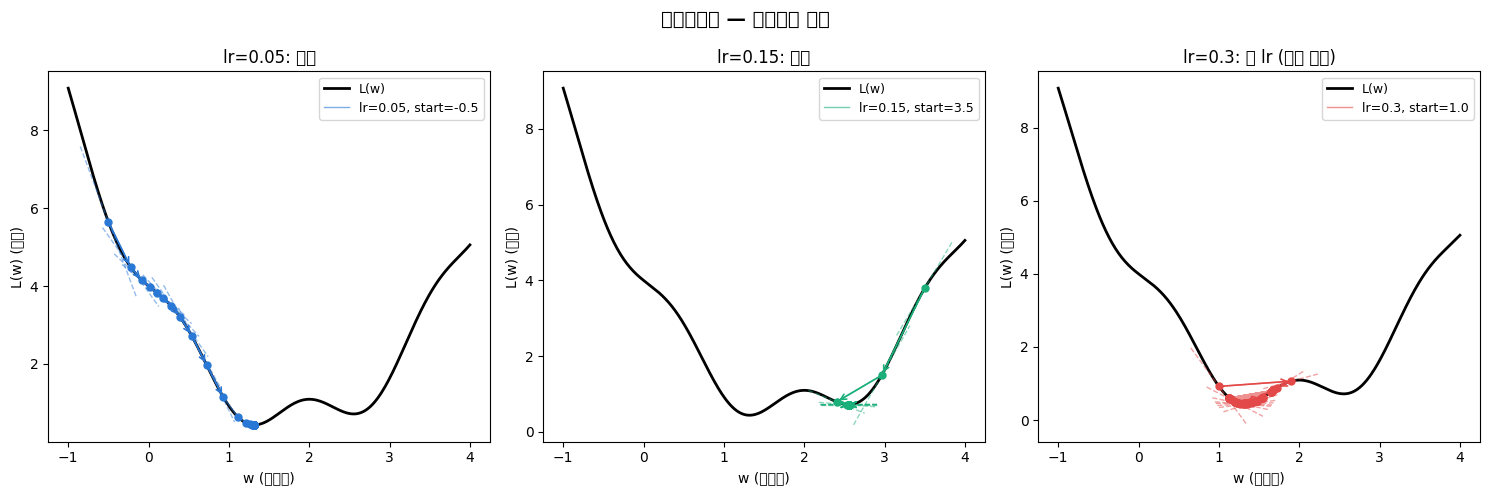

핵심 요약:
• lr 너무 작 → 수렴 느림   (테일러 1차 근사 유효 범위 내)
• lr 적당   → 안정 수렴   (2차 미분으로 최적 lr 추정 가능: Newton's method)
• lr 너무 큼 → 발산/진동  (테일러 근사 무효 구간 초과)


In [4]:
import numpy as np                                             # 수치 연산(배열, 수학함수) 라이브러리
import matplotlib.pyplot as plt                                # 그래프 시각화 라이브러리

# ── Gradient Descent 시각화 ──────────────────────────────────────────────────
np.random.seed(42)                                             # 난수 시드 고정 (재현성 확보용, 현재 코드에서는 랜덤 사용 없음)

# [강의 4~5p, 7p] 미분의 기본 법칙과 연쇄법칙(Chain Rule)을 적용한 도함수 도출
# 손실함수 L(w)에 대한 1차 도함수(기울기) dL(w) 즉, f'(x)를 수학적으로 계산하여 정의
L  = lambda w: (w - 2)**2 + 0.5*np.sin(4*w) + 0.3*w            # 손실함수 L(w) 정의: 이차항 + 진동항(sin) + 선형항의 합
dL = lambda w: 2*(w-2) + 2*np.cos(4*w) + 0.3                   # L(w)의 도함수 dL(w) = L'(w)
                                                                # → (w-2)^2 의 미분: 2(w-2)  [거듭제곱 미분법칙]
                                                                # → 0.5*sin(4w)의 미분: 0.5*4*cos(4w)=2cos(4w) [연쇄법칙: 바깥(sin)미분×안(4w)미분]
                                                                # → 0.3*w의 미분: 0.3 [상수곱 미분법칙]

def gradient_descent(start, lr, n_steps):                      # 경사하강법 함수: 시작점, 학습률, 반복횟수를 입력받음
    path = [start]                                              # 매 스텝의 w 값을 저장할 리스트, 초기값은 시작점
    for _ in range(n_steps):                                    # n_steps번 반복하여 w를 갱신
        # [강의 15p, 21~22p] 기울기의 역방향(-방향)으로 이동하는 업데이트 규칙
        # 도함수의 제곱은 양수이므로 역방향 이동 시 손실이 항상 감소함을 테일러 전개로 증명 가능.
        # 또한, f'(x)=0 인 임계점(Critical Point)에 도달하면 이동을 멈춤.
        path.append(path[-1] - lr * dL(path[-1]))               # w_new = w_old - lr * L'(w_old) : 기울기 반대 방향으로 lr만큼 이동
    return np.array(path)                                       # 리스트를 numpy 배열로 변환하여 반환 (전체 이동 경로)

w_range = np.linspace(-1, 4, 500)                               # 그래프에 그릴 L(w) 곡선용 w 값 범위 (-1~4, 500개 점)
starts  = [-0.5, 3.5, 1.0]                                      # 세 가지 실험의 시작 w 값
lrs     = [0.05, 0.15, 0.30]                                    # 세 가지 실험의 학습률(lr) 값

colors_gd = ['#2a78d6','#1baf7a','#e34948']                     # 각 실험을 구분할 색상 (파랑/초록/빨강)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))                 # 1행 3열의 서브플롯 생성 (실험 3개를 나란히 배치)
fig.suptitle("경사하강법 — 학습률과 수렴", fontsize=14, fontweight='bold')  # 전체 그림 제목

tangent_half_width = 0.35  # 접선을 그릴 x축 반경                  # 각 점에서 그릴 접선 선분의 좌우 폭 설정값

for ax, (start, lr, c) in zip(axes, zip(starts, lrs, colors_gd)):   # 세 서브플롯(ax)에 각각 (시작점, 학습률, 색상) 매칭하여 반복
    path = gradient_descent(start, lr, 60)                      # 해당 시작점/학습률로 60번 경사하강법 수행, 경로 저장
    ax.plot(w_range, L(w_range), 'k-', lw=2, label='L(w)')       # 손실함수 L(w) 곡선을 검은 실선으로 그림 (배경 곡선)
    ax.scatter(path, L(path), c=c, s=25, zorder=5)               # 경사하강법이 지나온 각 w 지점을 점으로 표시
    ax.plot(path, L(path), '-', color=c, lw=1, alpha=0.6,        # 지나온 점들을 얇은 선으로 연결
            label=f'lr={lr}, start={start}')                     # 범례에 학습률과 시작점 표시

    # 화살표 + 접선(기울기)
    for i in range(min(10, len(path)-1)):                        # 경로의 앞부분 최대 10스텝까지만 화살표/접선을 그림 (가독성용)
        ax.annotate('', xy=(path[i+1], L(path[i+1])),            # i+1번째 점을 화살표 끝점(xy)으로 지정
                    xytext=(path[i], L(path[i])),                 # i번째 점을 화살표 시작점(xytext)으로 지정
                    arrowprops=dict(arrowstyle='->', color=c, lw=1.2))  # 화살표 스타일: 색상/두께 지정, w_i → w_{i+1} 이동을 시각화

        # [강의 13p, 15p] 테일러 급수를 이용한 1차 근사식: y = f(a) + f'(a)(x - a)
        # 2차 이상의 항을 버린 '접선의 방정식'으로, 현재 가중치에서 손실함수의 변화를 예측함
        w_i   = path[i]                                          # 현재 스텝의 w 값 (테일러 전개 기준점 a = w_i)
        slope = dL(w_i)                                           # 그 지점에서의 기울기 f'(a) = dL(w_i)
        x_tan = np.array([w_i - tangent_half_width, w_i + tangent_half_width])  # 접선을 그릴 x축 구간 (w_i 좌우로 폭만큼)
        y_tan = L(w_i) + slope * (x_tan - w_i)                    # 접선의 y값 계산: f(a) + f'(a)(x-a) [1차 테일러 근사식]
        ax.plot(x_tan, y_tan, '--', color=c, lw=1, alpha=0.5)     # 접선을 점선으로 그려 실제 곡선과의 근사 정도를 비교 가능하게 함

    ax.set_xlabel('w (가중치)'); ax.set_ylabel('L(w) (손실)')      # x축(가중치), y축(손실) 라벨 설정
    ax.set_title(f'lr={lr}: {"적절" if 0.05<=lr<=0.15 else "큰 lr (진동 위험)"}')  # 학습률 크기에 따른 상태를 제목에 표시
    ax.legend(fontsize=9)                                         # 각 서브플롯에 범례 표시

plt.tight_layout()                                                # 서브플롯 간 여백을 자동으로 조정
plt.show()                                                        # 그래프 출력

print("핵심 요약:")                                                # 결과 해석을 텍스트로 요약 출력 시작
print("• lr 너무 작 → 수렴 느림   (테일러 1차 근사 유효 범위 내)")     # lr이 작을 때: 근사가 항상 유효하지만 수렴 속도가 느림
# [강의 17~18p, 24p] 2차 미분 테스트(f''(x)>0)를 활용하여 곡률을 구하면 최적의 이동 보폭을 조절할 수 있음
print("• lr 적당   → 안정 수렴   (2차 미분으로 최적 lr 추정 가능: Newton's method)")  # lr이 적절할 때: 곡률(2차 미분) 기반 최적 보폭에 가까워 안정적으로 수렴
# [강의 32p] 보폭(lr)이 커지면 테일러 급수의 나머지 항(R_n) 오차가 급증하여 1차 근사가 무효화되고 발산함
print("• lr 너무 큼 → 발산/진동  (테일러 근사 무효 구간 초과)")        # lr이 클 때: 근사 오차(잔여항)가 커져 발산/진동 발생

# 총 정리
# 강의자료 챕터별 3중 의미 정리

## 1. 도함수의 정의 (10.1-1)
- **수학적 의미**: $f'(x) = \lim_{h\to0}\frac{f(x+h)-f(x)}{h}$ — 한 점에서의 순간 변화율, 즉 그래프의 접선 기울기
- 비즈니스 의미 : A 변수를 1단위를 늘리면, 결과가 얼마나 다이나믹하게 변하는가? 광고비 1원 추가시, 전환율 변화(한계효용)
- 딥러닝 의미 : 손실함수 $L(W)$를 파라미터 $w$로 미분한 값, 파라미터를 어느 방향, 얼마나 조정해야 손실이 줄어드는지 알려주는 가장 기초적인 신호


## 2. 미분의 법칙 & 연쇄법칙 (10.1-2, 10.1-3)
- **수학적 의미**: 덧셈·상수곱·곱셈·나눗셈 규칙, 그리고 합성함수 $u(x)=g(f(x))$의 미분 $u'(x)=g'(f(x))f'(x)$
- 비즈니스 의미 : 여러 단계로 연결된 프로세스(원가 => 생산량 => 매출 => 순이익)에서 한 단계의 변화가 최종 결과에 미치는 영향, 단계별로 곱해서 추적하는 논리 Causal Chain Analysis
- 딥러닝 의미 : 오차 역전파의 이론적 핵심적인 근거가 되며, 마지막 층 손실의 기울기를 맨 앞쪽 체인룰로 곱하면, 모든 가중치의 그레디언트를 구할 수 있음


## 3. 고차 도함수 (10.1-4)
- **수학적 의미**: $f''(x)$는 곡률(휘어짐)을, $f^{(n)}(x)$는 함수의 미세한 구조를 나타냄
- 비즈니스 의미 : 성장률의 변화 속도를 감지, 매출이 1차적으로는 증가함. 성장이 가속화되고 있다 or 둔화되고 있다.
- 딥러닝 의미 : 손실 곡면의 곡률 정보 제공, 곡률이 급격한 구간 또는 완만한 구간이나 판단


## 4. 평균값 정리 (10.1-5)
- **수학적 의미**: 구간 $[a,b]$에서 평균 변화율과 같은 순간 변화율을 갖는 점 $c$가 반드시 존재

- 비즈니스 의미 : 1년 평균 성잘률이 5%, 특정한 시점에 아주 정확하게 5% 성장 속도였던 시점이 존재함 성장률 10%, 성장률 1% 사이를 연결해주는 일종의 논리적 연결고리
- 딥러닝 의미 : 다수의 파라미터 값 사이의 손실 변화를 중간에서 제어할 수 있다는 이론적 토대 제공 => 최적화 알고리즘의 수렴성... 증명

## 5. 테일러 급수 (10.2-1, 10.3-1~4)
- **수학적 의미**: 복잡한 함수를 $x^*$ 근처에서 다항식(1차+2차+3차+...)으로 근사. 1차만 쓰면 접선, 2차까지 쓰면 포물선 근사
- 비즈니스 의미 : 시장이 매우 복잡함 => 현재 시점에서 선형 근사(1차 함수)만 사용해도 충분히 예측 가능하다는 실무적 전제 제공, 회귀분석이면 충분하다.
- 딥러닝 의미 : 경사하강법이 1차 테일러 근사 활용 손실함수 2차로 모두 정리 중


## 6. 2차 미분 테스트 & 최소자/임계점 (10.2-2, 10.2-3, 10.2-4)
- **수학적 의미**: $f'(x^*)=0$(임계점)이고 $f''(x^*)>0$이면 국소 최소자, $f''(x^*)<0$이면 국소 최대자
- 비즈니스 의미 : 이익함수, 비용함수의 최적점을 수학적으로 검증하는 도구, "이 지점이 진짜 최적인가?"
- 딥러닝 의미 : 학습이 멈춘 지점이 실제 좋은 지점(best)인지 아닌지 구분할 수 있도록 도와주는 기준점

## 7. 테일러 급수의 잔여항과 수렴 (10.3-2, 10.3-3)
- **수학적 의미**: 무한 급수로 갈 때 남는 오차항 $R_n = \frac{f^{(n)}(c)}{n!}(x-x^*)^n$이 0으로 수렴해야 근사가 정당화됨
- 비즈니스 의미 : 실제 회귀분석 예) 모델이 실제 상황에 적용할 때, 실제 근사한 것인지? 아니면 많이 벗어났는지 정략적으로 관리하는 리스크 관리 개념
- 딥러닝 의미 : 학습률(lr)이 커질수록, 1차 or 2차 근사의 잔여항이 커져서 실제 손실 변화가 예측과 많이 벗어날 수 있다. => 이걸 감지해야함